In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('C:/Users/aarus/Desktop/projects/bank-churn-mlops/data/Bank Customer Churn Prediction.csv')
df.head(10)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,15574012,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,15592531,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,15656148,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,15792365,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,15592389,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [4]:
print(df.columns)

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')


In [5]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(10000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0

In [6]:
df=df.drop(columns=['customer_id','country','gender'])

In [7]:
df.head()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,42,2,0.00,1,1,1,101348.88,1
1,608,41,1,83807.86,1,0,1,112542.58,0
2,502,42,8,159660.80,3,1,0,113931.57,1
3,699,39,1,0.00,2,0,0,93826.63,0
4,850,43,2,125510.82,1,1,1,79084.10,0


*dont want gender and country leading to a bias
now lets check class imbalance*


In [8]:
print(df['churn'].value_counts())
print(df['churn'].value_counts(normalize='true')*100)

churn
0    7963
1    2037
Name: count, dtype: int64
churn
0    79.63
1    20.37
Name: proportion, dtype: float64


**As you can see, the data is highly imbalanced, so we had an option of generating random samples, but it's a risky thing. When working on financial models, we need an accurate representation of data instead of some randomly generated values, which may or may not be true, so what we need to do is penalize the minority classes more rigorously.
tell the model to penalize mistakes on the minority class more heavily. No fake data, just rebalancing importance. Most ML models like XGBoost have a built-in scale_pos_weight parameter for this.*


In [9]:
df.describe()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


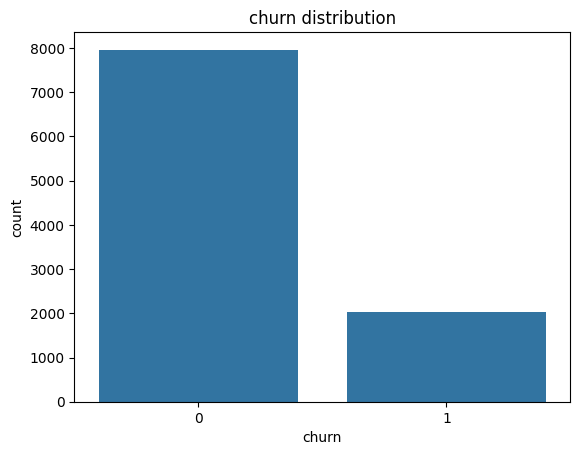

In [10]:
sns.countplot(x='churn',data=df)
plt.title('churn distribution')
plt.show()

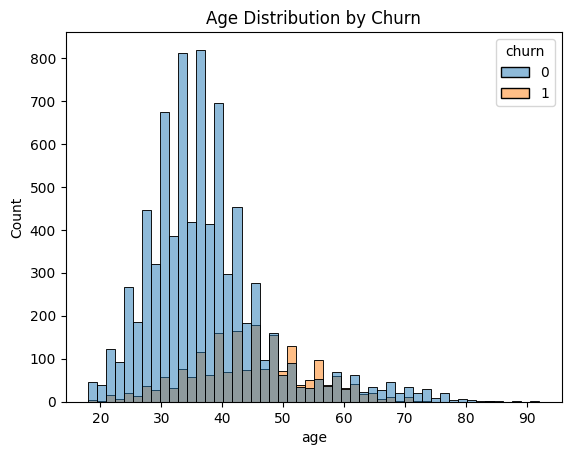

In [11]:
sns.histplot(data=df, x='age', hue='churn', bins=50)
plt.title('Age Distribution by Churn')
plt.show()

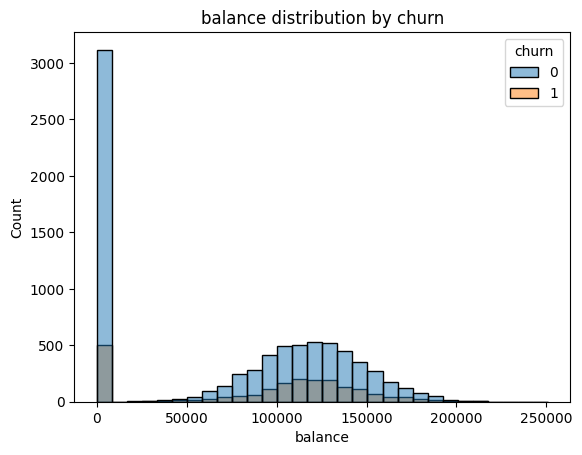

In [12]:
sns.histplot(data=df,x='balance',hue='churn',bins=30)
plt.title('balance distribution by churn')
plt.show()

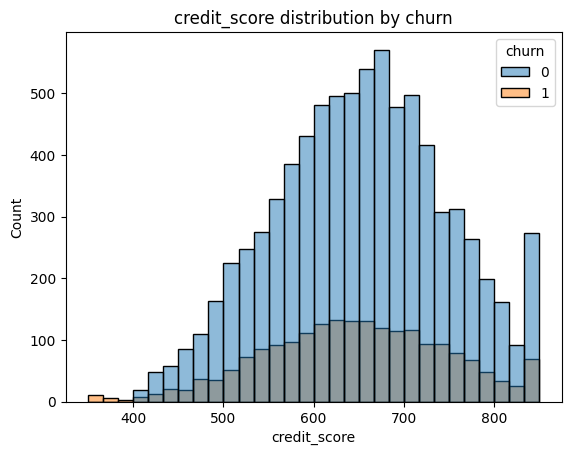

In [13]:
sns.histplot(data=df,x='credit_score',hue='churn',bins=30)
plt.title('credit_score distribution by churn')
plt.show()

In [14]:
x=df.drop(columns='churn')
y=df['churn']

In [15]:
x.head()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


In [16]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: churn, dtype: int64

In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)
print(x_train.shape,x_test.shape)
print(y_train.shape,y_test.shape)

(8000, 8) (2000, 8)
(8000,) (2000,)


*scaling is done to bring all the features to the same scale so no feature dominates the others
Great question!*

*fit_transform on X_train → learns the scale (mean, std) FROM the training data, then applies it
transform on X_test → applies the same scale learned from training data to the test data*

*If we did fit_transform on X_test too, it would learn a new scale from test data — which is wrong because*


In [18]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report
lr=LogisticRegression(class_weight='balanced',random_state=42)
lr.fit(x_train_scaled,y_train)
y_pred_lr=lr.predict(x_test_scaled)
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1607
           1       0.36      0.70      0.48       393

    accuracy                           0.70      2000
   macro avg       0.63      0.70      0.63      2000
weighted avg       0.80      0.70      0.73      2000



In [20]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(class_weight='balanced',random_state=42,n_estimators=200)
rf.fit(x_train,y_train)
y_pred_rf=rf.predict(x_test)
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1607
           1       0.74      0.41      0.53       393

    accuracy                           0.86      2000
   macro avg       0.81      0.69      0.72      2000
weighted avg       0.84      0.86      0.84      2000



In [21]:
from xgboost import XGBClassifier
xg=XGBClassifier(scale_pos_weight=7963/2037,random_state=42)
xg.fit(x_train,y_train)
y_pred_xg=xg.predict(x_test)
print(classification_report(y_test,y_pred_xg))

              precision    recall  f1-score   support

           0       0.90      0.85      0.88      1607
           1       0.50      0.61      0.55       393

    accuracy                           0.81      2000
   macro avg       0.70      0.73      0.71      2000
weighted avg       0.82      0.81      0.81      2000



In [22]:
from sklearn.model_selection import GridSearchCV

In [23]:
param_grid={
    'C':[0.01,0.1,1,10,100],
    'penalty':['l1','l2'],
    'solver':['liblinear']
}
grid_search_lr=GridSearchCV(LogisticRegression(class_weight='balanced',random_state=42),param_grid,cv=5,scoring='recall',n_jobs=-1)

#1 : Runs sequentially on a single core (best for debugging).
#-1 : Utilizes all available CPU cores/threads.
#n (where \(n > 1\)) : Runs exactly \(n\) concurrent jobs/processes.
#-n : Uses all CPUs except for \(n-1\) (e.g., -2 uses all but one CPU)
grid_search_lr.fit(x_train_scaled,y_train)
print('best parameters are: ' ,grid_search_lr.best_params_)
print('best score or recall is',grid_search_lr.best_score_)

best parameters are:  {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
best score or recall is 0.7098524723849062


In [24]:
best_lr=grid_search_lr.best_estimator_
y_pred_best_lr=best_lr.predict(x_test_scaled)
print(classification_report(y_test,y_pred_best_lr))

              precision    recall  f1-score   support

           0       0.91      0.67      0.77      1607
           1       0.35      0.73      0.47       393

    accuracy                           0.68      2000
   macro avg       0.63      0.70      0.62      2000
weighted avg       0.80      0.68      0.71      2000



In [29]:
parameters_for_rf={
    'n_estimators':[100,200,300],
    'max_depth':[2,5,7],
    'min_samples_split':[2,5,10]}
grid_search_rf=GridSearchCV(RandomForestClassifier(class_weight='balanced',random_state=42),parameters_for_rf,cv=5,scoring='recall',n_jobs=-1)
grid_search_rf.fit(x_train,y_train)
print('best_param for rf',grid_search_rf.best_params_)
print('best_score for rf',grid_search_rf.best_score_)
best_rf=grid_search_rf.best_estimator_
y_pred_best_rf=best_rf.predict(x_test)
print(classification_report(y_test,y_pred_best_rf))
    

best_param for rf {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
best_score for rf 0.6928145155311735
              precision    recall  f1-score   support

           0       0.92      0.81      0.86      1607
           1       0.48      0.72      0.58       393

    accuracy                           0.79      2000
   macro avg       0.70      0.77      0.72      2000
weighted avg       0.84      0.79      0.81      2000



In [32]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'scale_pos_weight': [7963/2037]
}

grid_search_xgb = GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid_xgb,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_search_xgb.fit(x_train, y_train)

print("Best params:", grid_search_xgb.best_params_)
print("Best recall:", grid_search_xgb.best_score_)
best_xg=grid_search_xgb.best_estimator_
y_pred_best_xg=best_xg.predict(x_test)
print(classification_report(y_test,y_pred_best_xg))

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 3.9091801669121256}
Best recall: 0.7183556972347839
              precision    recall  f1-score   support

           0       0.93      0.78      0.85      1607
           1       0.46      0.76      0.57       393

    accuracy                           0.78      2000
   macro avg       0.70      0.77      0.71      2000
weighted avg       0.84      0.78      0.80      2000



In [33]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("bank-churn-prediction")

2026/06/02 19:10:07 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/02 19:10:08 INFO mlflow.store.db.utils: Updating database tables
2026/06/02 19:10:10 INFO mlflow.tracking.fluent: Experiment with name 'bank-churn-prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///C:/Users/aarus/Desktop/projects/bank-churn-mlops/notebooks/mlruns/1', creation_time=1780407610774, experiment_id='1', last_update_time=1780407610774, lifecycle_stage='active', name='bank-churn-prediction', tags={}, trace_location=None, workspace='default'>

In [34]:
import joblib

joblib.dump(grid_search_rf.best_estimator_, '../models/random_forest_model.pkl')
print("Model saved!")

Model saved!
